In [2]:
! pip install pandas

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/11.0 MB ? eta -:--:--
   ---------------------------------------- 11.0/11.0 MB 140.8 MB/s  0:00:00

   ---------------------------------------- 0/3 [pytz]
   ---------------------------------------- 0/3 [pytz]
   ------------- -------------------------- 1/3 [tzdata]
   ------------- -------------------------- 1/3 [tzdata]
   -------------------------- ------------- 2/3 [pandas]
   -------------------------- ------------- 2/3 [pandas]
   -------------------------- ------------- 2/3 [pandas]
   -------------------------- ------------- 2/3 [pandas]
   -------------------------- ------------- 2/3 [pandas]
   -------------------------- ------------- 2/3 [pandas]
   -------------------------- ------------- 2/3 [pandas]
   -------------------------- ------------- 2/3 [pandas]
   -------------------------- ------------- 2/3 [pandas]
   -------------------------- -------

C:\Users\mkarim1\AppData\Local\Temp\ipykernel_29192\1723127239.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0,0].boxplot(time_data, labels=models)
C:\Users\mkarim1\AppData\Local\Temp\ipykernel_29192\1723127239.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0,1].boxplot(grade_data, labels=models)
C:\Users\mkarim1\AppData\Local\Temp\ipykernel_29192\1723127239.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0,2].boxplot(gleu_data, labels=models)
C:\Users\mkarim1\AppData\Local\Temp\ipykernel_29192\1723127239.py:48: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been

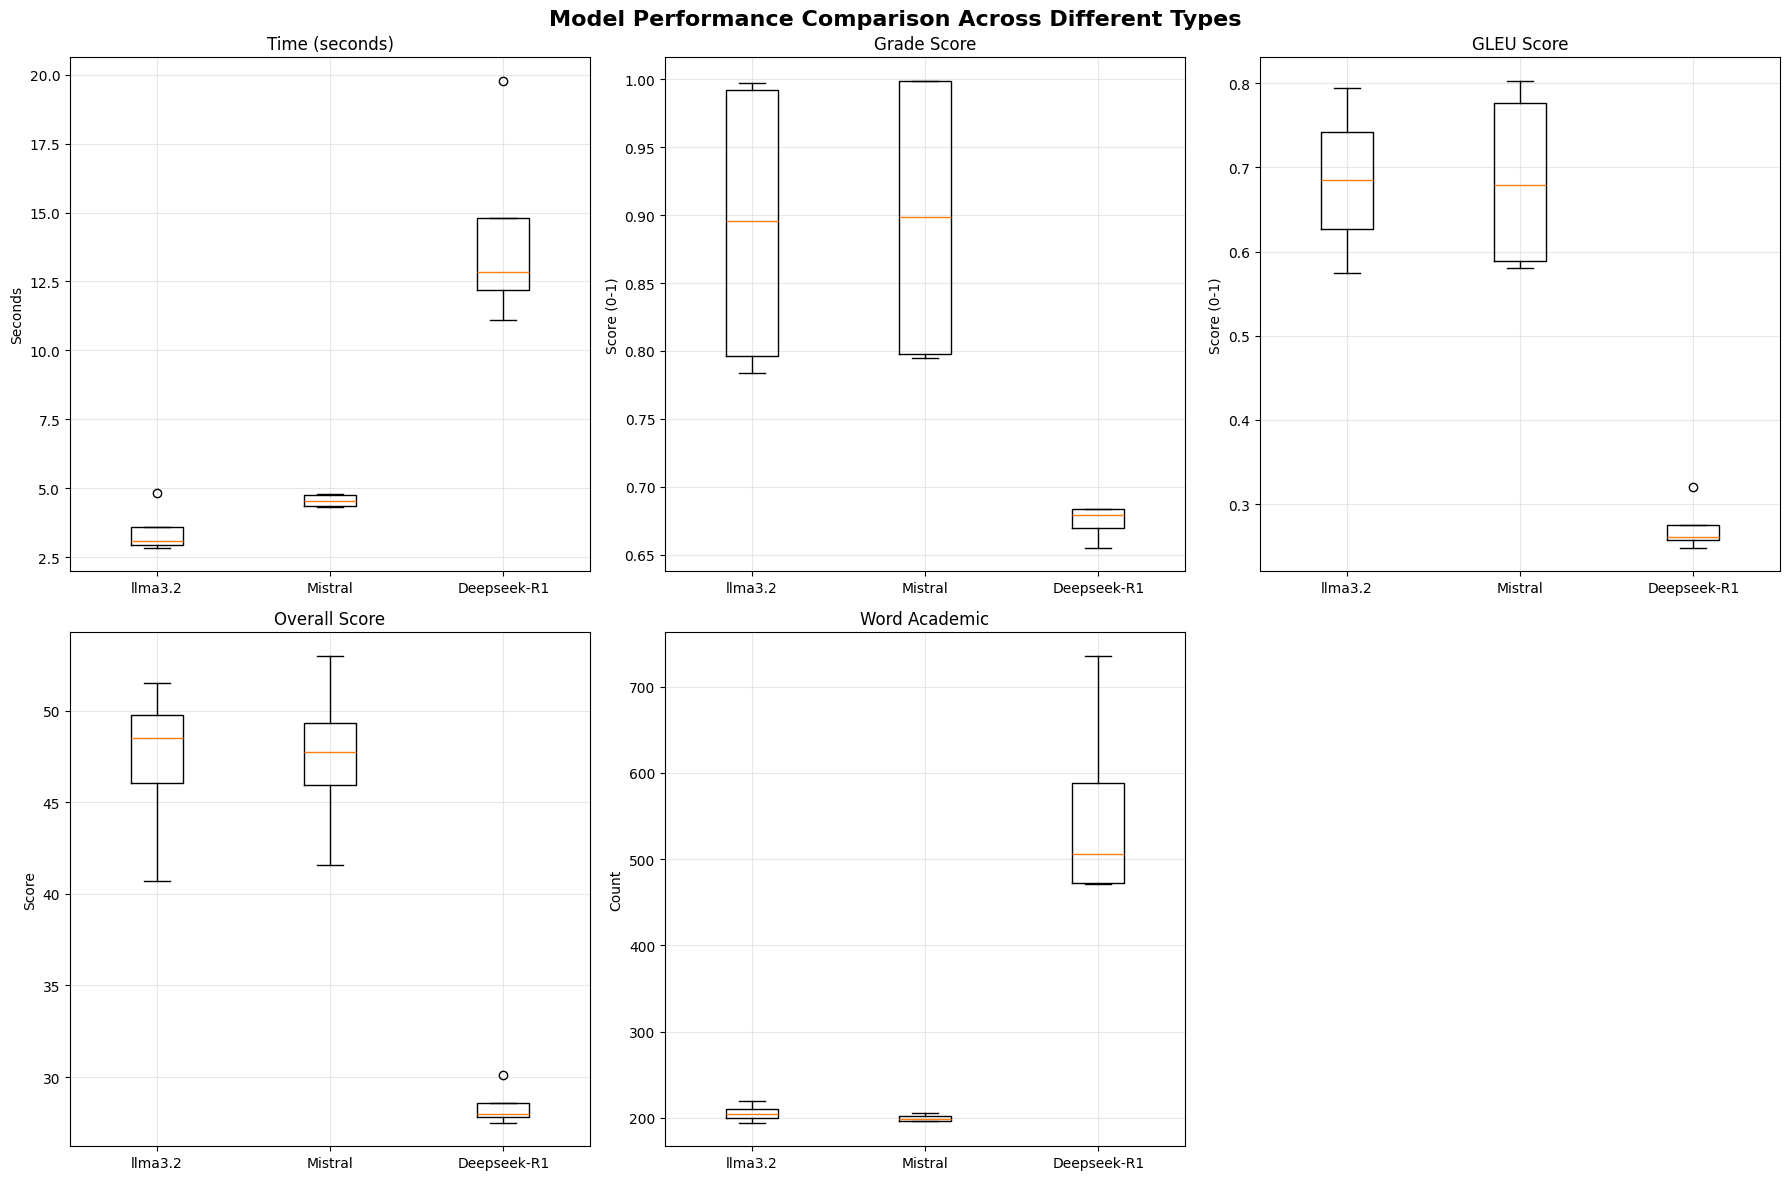

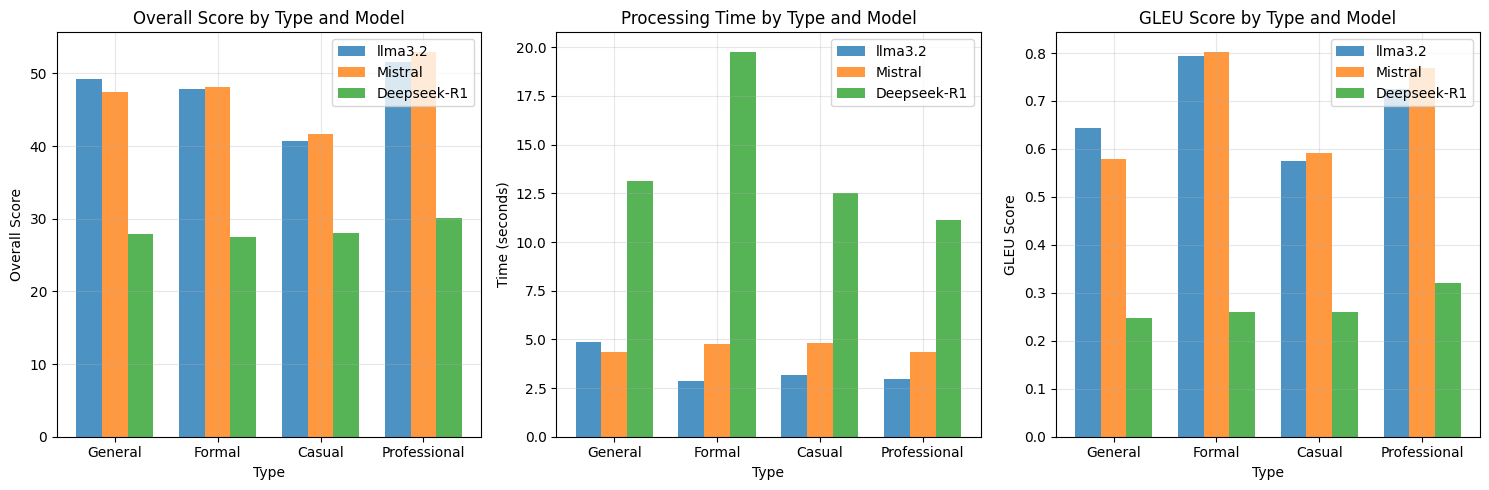

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Create the data structure
data = {
    'Types': ['General', 'General', 'General', 'Formal', 'Formal', 'Formal', 
             'Casual', 'Casual', 'Casual', 'Professional', 'Professional', 'Professional'],
    'Model': ['llma3.2', 'Mistral', 'Deepseek-R1', 'llma3.2', 'Mistral', 'Deepseek-R1',
             'llma3.2', 'Mistral', 'Deepseek-R1', 'llma3.2', 'Mistral', 'Deepseek-R1'],
    'Time': [4.84, 4.35, 13.12, 2.84, 4.74, 19.78, 3.19, 4.79, 12.54, 2.96, 4.33, 11.12],
    'Grade': [0.997, 0.999, 0.684, 0.8, 0.799, 0.655, 0.784, 0.795, 0.675, 0.991, 0.999, 0.684],
    'GLEU': [0.644, 0.58, 0.248, 0.794, 0.803, 0.261, 0.574, 0.591, 0.261, 0.725, 0.768, 0.32],
    'Overall_Score': [49.2, 47.4, 27.9, 47.8, 48.1, 27.5, 40.7, 41.6, 28.1, 51.5, 53, 30.1],
    'Word_Academic': [194, 196, 471, 202, 201, 736, 219, 206, 539, 207, 197, 472]
}

df = pd.DataFrame(data)

# Create subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Model Performance Comparison Across Different Types', fontsize=16, fontweight='bold')

# Box plot for Time
models = ['llma3.2', 'Mistral', 'Deepseek-R1']
time_data = [df[df['Model'] == model]['Time'].values for model in models]
axes[0,0].boxplot(time_data, labels=models)
axes[0,0].set_title('Time (seconds)')
axes[0,0].set_ylabel('Seconds')
axes[0,0].grid(True, alpha=0.3)

# Box plot for Grade
grade_data = [df[df['Model'] == model]['Grade'].values for model in models]
axes[0,1].boxplot(grade_data, labels=models)
axes[0,1].set_title('Grade Score')
axes[0,1].set_ylabel('Score (0-1)')
axes[0,1].grid(True, alpha=0.3)

# Box plot for GLEU
gleu_data = [df[df['Model'] == model]['GLEU'].values for model in models]
axes[0,2].boxplot(gleu_data, labels=models)
axes[0,2].set_title('GLEU Score')
axes[0,2].set_ylabel('Score (0-1)')
axes[0,2].grid(True, alpha=0.3)

# Box plot for Overall Score
overall_data = [df[df['Model'] == model]['Overall_Score'].values for model in models]
axes[1,0].boxplot(overall_data, labels=models)
axes[1,0].set_title('Overall Score')
axes[1,0].set_ylabel('Score')
axes[1,0].grid(True, alpha=0.3)

# Box plot for Word Academic
word_data = [df[df['Model'] == model]['Word_Academic'].values for model in models]
axes[1,1].boxplot(word_data, labels=models)
axes[1,1].set_title('Word Academic')
axes[1,1].set_ylabel('Count')
axes[1,1].grid(True, alpha=0.3)

# Remove empty subplot
axes[1,2].axis('off')

plt.tight_layout()
plt.show()

# Additional plot: Performance by Type
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Overall Score by Type for each model
types = ['General', 'Formal', 'Casual', 'Professional']
llma_scores = [49.2, 47.8, 40.7, 51.5]
mistral_scores = [47.4, 48.1, 41.6, 53]
deepseek_scores = [27.9, 27.5, 28.1, 30.1]

x = np.arange(len(types))
width = 0.25

axes[0].bar(x - width, llma_scores, width, label='llma3.2', alpha=0.8)
axes[0].bar(x, mistral_scores, width, label='Mistral', alpha=0.8)
axes[0].bar(x + width, deepseek_scores, width, label='Deepseek-R1', alpha=0.8)
axes[0].set_xlabel('Type')
axes[0].set_ylabel('Overall Score')
axes[0].set_title('Overall Score by Type and Model')
axes[0].set_xticks(x)
axes[0].set_xticklabels(types)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Time by Type
llma_time = [4.84, 2.84, 3.19, 2.96]
mistral_time = [4.35, 4.74, 4.79, 4.33]
deepseek_time = [13.12, 19.78, 12.54, 11.12]

axes[1].bar(x - width, llma_time, width, label='llma3.2', alpha=0.8)
axes[1].bar(x, mistral_time, width, label='Mistral', alpha=0.8)
axes[1].bar(x + width, deepseek_time, width, label='Deepseek-R1', alpha=0.8)
axes[1].set_xlabel('Type')
axes[1].set_ylabel('Time (seconds)')
axes[1].set_title('Processing Time by Type and Model')
axes[1].set_xticks(x)
axes[1].set_xticklabels(types)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# GLEU Score by Type
llma_gleu = [0.644, 0.794, 0.574, 0.725]
mistral_gleu = [0.58, 0.803, 0.591, 0.768]
deepseek_gleu = [0.248, 0.261, 0.261, 0.32]

axes[2].bar(x - width, llma_gleu, width, label='llma3.2', alpha=0.8)
axes[2].bar(x, mistral_gleu, width, label='Mistral', alpha=0.8)
axes[2].bar(x + width, deepseek_gleu, width, label='Deepseek-R1', alpha=0.8)
axes[2].set_xlabel('Type')
axes[2].set_ylabel('GLEU Score')
axes[2].set_title('GLEU Score by Type and Model')
axes[2].set_xticks(x)
axes[2].set_xticklabels(types)
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

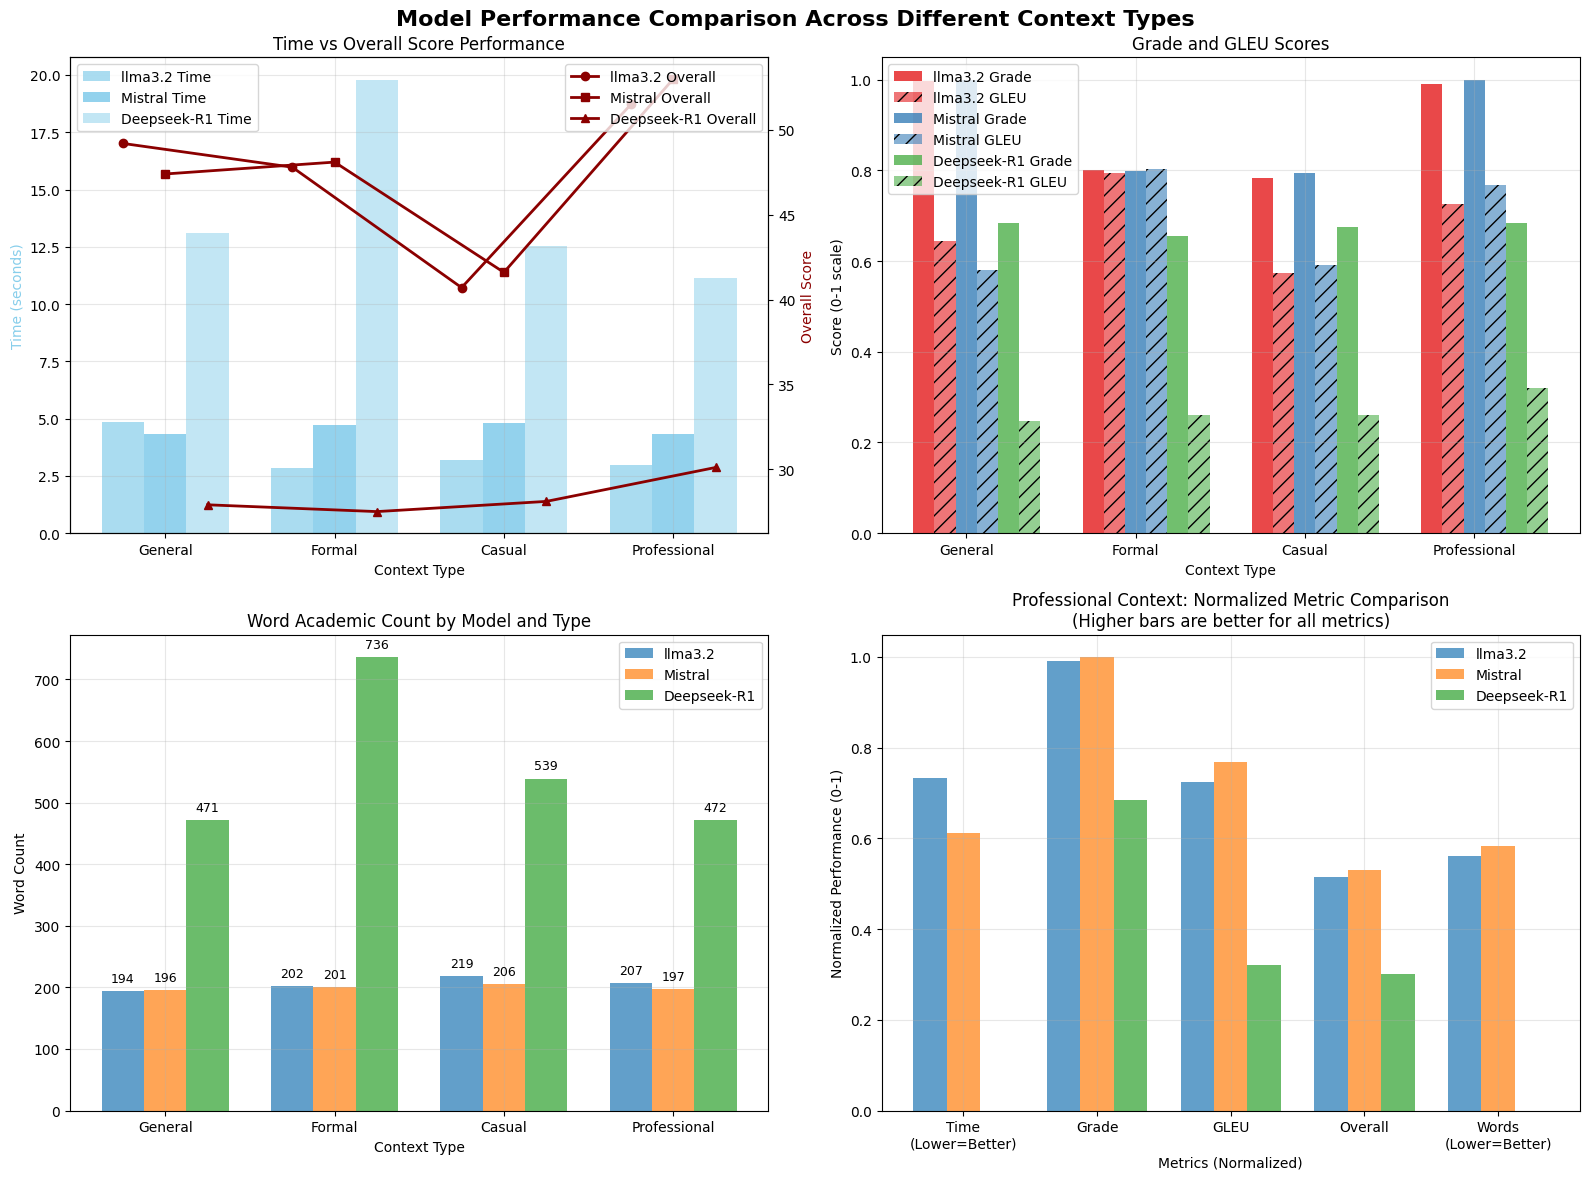

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Data organized by model
models = ['llma3.2', 'Mistral', 'Deepseek-R1']
types = ['General', 'Formal', 'Casual', 'Professional']

# Metrics data organized by [General, Formal, Casual, Professional] for each model
time_data = {
    'llma3.2': [4.84, 2.84, 3.19, 2.96],
    'Mistral': [4.35, 4.74, 4.79, 4.33],
    'Deepseek-R1': [13.12, 19.78, 12.54, 11.12]
}

grade_data = {
    'llma3.2': [0.997, 0.8, 0.784, 0.991],
    'Mistral': [0.999, 0.799, 0.795, 0.999],
    'Deepseek-R1': [0.684, 0.655, 0.675, 0.684]
}

gleu_data = {
    'llma3.2': [0.644, 0.794, 0.574, 0.725],
    'Mistral': [0.58, 0.803, 0.591, 0.768],
    'Deepseek-R1': [0.248, 0.261, 0.261, 0.32]
}

overall_data = {
    'llma3.2': [49.2, 47.8, 40.7, 51.5],
    'Mistral': [47.4, 48.1, 41.6, 53],
    'Deepseek-R1': [27.9, 27.5, 28.1, 30.1]
}

word_data = {
    'llma3.2': [194, 202, 219, 207],
    'Mistral': [196, 201, 206, 197],
    'Deepseek-R1': [471, 736, 539, 472]
}

# Create the plot
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Model Performance Comparison Across Different Context Types', fontsize=16, fontweight='bold')

# Set up the bar positions
x = np.arange(len(types))
width = 0.25

# Plot 1: Time and Overall Score (dual axis)
color1 = 'skyblue'
color2 = 'coral'

bars1 = ax1.bar(x - width, time_data['llma3.2'], width, label='llma3.2 Time', color=color1, alpha=0.7)
bars2 = ax1.bar(x, time_data['Mistral'], width, label='Mistral Time', color=color1, alpha=0.9)
bars3 = ax1.bar(x + width, time_data['Deepseek-R1'], width, label='Deepseek-R1 Time', color=color1, alpha=0.5)

ax1_twin = ax1.twinx()
ax1_twin.plot(x - width, overall_data['llma3.2'], 'o-', color='darkred', label='llma3.2 Overall', linewidth=2)
ax1_twin.plot(x, overall_data['Mistral'], 's-', color='darkred', label='Mistral Overall', linewidth=2)
ax1_twin.plot(x + width, overall_data['Deepseek-R1'], '^-', color='darkred', label='Deepseek-R1 Overall', linewidth=2)

ax1.set_xlabel('Context Type')
ax1.set_ylabel('Time (seconds)', color=color1)
ax1_twin.set_ylabel('Overall Score', color='darkred')
ax1.set_title('Time vs Overall Score Performance')
ax1.set_xticks(x)
ax1.set_xticklabels(types)
ax1.legend(loc='upper left')
ax1_twin.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# Plot 2: Grade and GLEU Scores
for i, model in enumerate(models):
    offset = width * (i - 1)
    ax2.bar(x + offset, grade_data[model], width/2, label=f'{model} Grade', alpha=0.8, 
            color=plt.cm.Set1(i))
    ax2.bar(x + offset + width/2, gleu_data[model], width/2, label=f'{model} GLEU', alpha=0.6,
            color=plt.cm.Set1(i), hatch='//')

ax2.set_xlabel('Context Type')
ax2.set_ylabel('Score (0-1 scale)')
ax2.set_title('Grade and GLEU Scores')
ax2.set_xticks(x)
ax2.set_xticklabels(types)
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Word Count comparison
word_bars = []
for i, model in enumerate(models):
    bars = ax3.bar(x + width*(i-1), word_data[model], width, label=model, alpha=0.7)
    word_bars.append(bars)
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height + 10,
                f'{int(height)}', ha='center', va='bottom', fontsize=9)

ax3.set_xlabel('Context Type')
ax3.set_ylabel('Word Count')
ax3.set_title('Word Academic Count by Model and Type')
ax3.set_xticks(x)
ax3.set_xticklabels(types)
ax3.legend()
ax3.grid(True, alpha=0.3)

# Plot 4: Radar chart-like comparison for Professional context (best performing)
professional_metrics = ['Time', 'Grade', 'GLEU', 'Overall', 'Words']
professional_values = {
    'llma3.2': [2.96, 0.991, 0.725, 51.5, 207],
    'Mistral': [4.33, 0.999, 0.768, 53, 197],
    'Deepseek-R1': [11.12, 0.684, 0.32, 30.1, 472]
}

# Normalize values for radar comparison (inverse for time and words where lower is better)
normalized_data = {}
for model in models:
    # For Time and Words, lower is better, so we invert
    time_norm = 1 - (professional_values[model][0] / max([professional_values[m][0] for m in models]))
    grade_norm = professional_values[model][1]  # Already 0-1
    gleu_norm = professional_values[model][2]   # Already 0-1
    overall_norm = professional_values[model][3] / 100  # Scale to 0-1
    words_norm = 1 - (professional_values[model][4] / max([professional_values[m][4] for m in models]))
    
    normalized_data[model] = [time_norm, grade_norm, gleu_norm, overall_norm, words_norm]

# Create radar-like bar comparison
radar_metrics = ['Time\n(Lower=Better)', 'Grade', 'GLEU', 'Overall', 'Words\n(Lower=Better)']
x_radar = np.arange(len(radar_metrics))

for i, model in enumerate(models):
    ax4.bar(x_radar + width*(i-1), normalized_data[model], width, label=model, alpha=0.7)

ax4.set_xlabel('Metrics (Normalized)')
ax4.set_ylabel('Normalized Performance (0-1)')
ax4.set_title('Professional Context: Normalized Metric Comparison\n(Higher bars are better for all metrics)')
ax4.set_xticks(x_radar)
ax4.set_xticklabels(radar_metrics)
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()